## 1. Imports & Configuration

In [1]:
import os
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

np.random.seed(0)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

## 2. Load Dataset & Initial Inspection

The dataset is sourced from Kaggle ([link](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)). Features `V1–V28` are PCA-transformed for confidentiality. Only `Time`, `Amount`, and `Class` retain their original meaning.

We check:
- Shape and data types
- Null values (a corrupted pipeline could introduce these)
- Class distribution — the critical imbalance problem

In [2]:
df = pd.read_csv('Data.zip', compression='zip')

print(f"Dataset shape: {df.shape}")
print(f"\nNull values: {df.isnull().sum().max()}")
print(f"\nClass distribution:\n{df['Class'].value_counts()}")
print(f"\nFraud rate: {df['Class'].mean() * 100:.4f}%")
df.describe()

Dataset shape: (284807, 31)

Null values: 0

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Imbalance

Visualising the imbalance makes the problem concrete. A naive model that predicts "not fraud" for every transaction would achieve **99.83% accuracy** — which is why accuracy is useless here and we optimise for **F1-score, Precision, and Recall** instead.

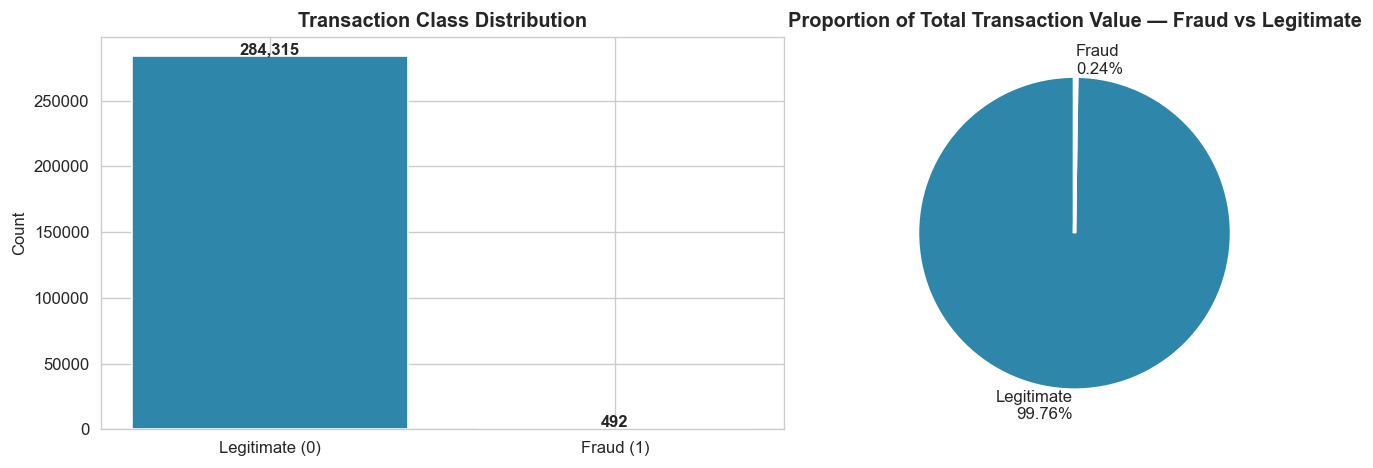

Fraud accounts for 0.24% of total transaction value.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=['#2E86AB', '#E84855'], edgecolor='white')
axes[0].set_title('Transaction Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Proportion of fraud by transaction amount
total = df['Amount'].sum()
fraud_amount = df.loc[df['Class'] == 1, 'Amount'].sum()
prop = fraud_amount / total * 100
axes[1].pie(
    [total - fraud_amount, fraud_amount],
    labels=[f'Legitimate\n{100-prop:.2f}%', f'Fraud\n{prop:.2f}%'],
    colors=['#2E86AB', '#E84855'],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proportion of Total Transaction Value — Fraud vs Legitimate', fontweight='bold')

plt.tight_layout()
plt.savefig('images/class_imbalance.png', bbox_inches='tight')
plt.show()

print(f"Fraud accounts for {prop:.2f}% of total transaction value.")

### 3.2 Distribution of `Amount` and `Time`

`Amount` and `Time` are the only non-PCA features. Before scaling, we inspect their distributions to confirm the presence of outliers — which informs our choice of scaler.

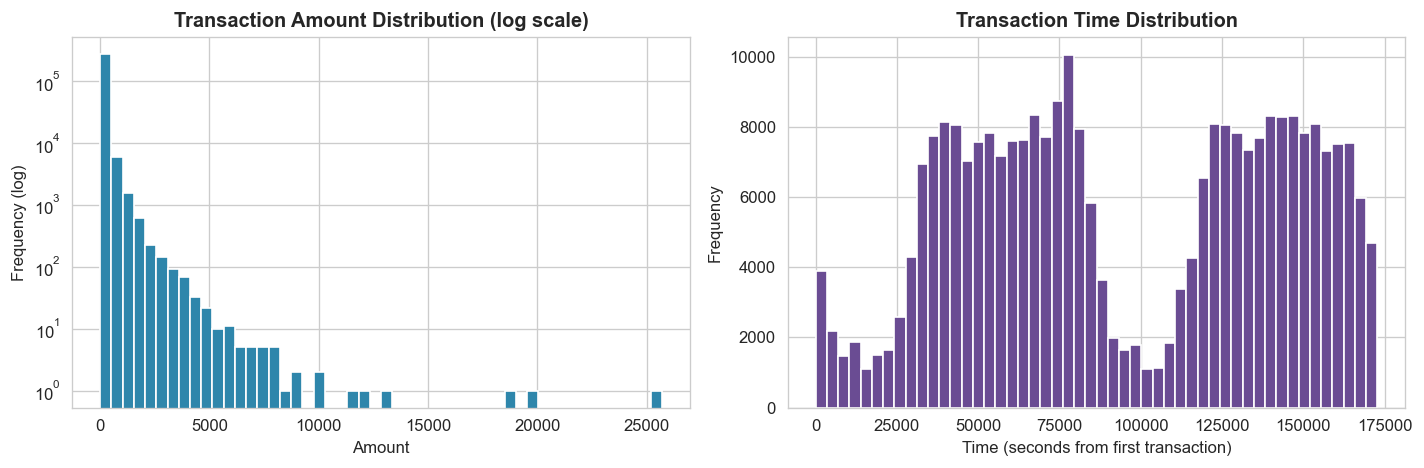

Amount — Max: 25691.16, Mean: 88.35, Std: 250.12
Extreme outliers confirm RobustScaler is the correct choice over StandardScaler.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Amount'], bins=50, color='#2E86AB', edgecolor='white', log=True)
axes[0].set_title('Transaction Amount Distribution (log scale)', fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency (log)')

axes[1].hist(df['Time'], bins=50, color='#6A4C93', edgecolor='white')
axes[1].set_title('Transaction Time Distribution', fontweight='bold')
axes[1].set_xlabel('Time (seconds from first transaction)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('images/amount_time_distributions.png', bbox_inches='tight')
plt.show()

print(f"Amount — Max: {df['Amount'].max():.2f}, Mean: {df['Amount'].mean():.2f}, Std: {df['Amount'].std():.2f}")
print(f"Extreme outliers confirm RobustScaler is the correct choice over StandardScaler.")

## 4. Train / Validation / Test Split

### Design Decision: Stratified 70/15/15 Split

With only 492 fraud cases in 284,807 transactions, a random split risks concentrating fraud cases unevenly. We use **stratified splitting** to guarantee the 0.17% fraud rate is preserved across all three sets.

**Why three sets instead of two?**
- **Train** — model learning
- **Validation** — hyperparameter tuning and model selection (used by the modelling team during development)
- **Test** — final unbiased evaluation, never touched until the end

Using the test set during model selection would constitute **data leakage** — the model would effectively "know" the test set, giving optimistically biased results.

In [5]:
X = df.drop(['Class'], axis=1)
y = df['Class']

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y, shuffle=True
)

# Second split: 15% val, 15% test (50/50 of the 30% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=0, stratify=y_temp, shuffle=True
)

print("Split sizes:")
print(f"  Train:      {len(X_train):>7,} rows | Fraud: {y_train.sum():>4} ({y_train.mean()*100:.2f}%)")
print(f"  Validation: {len(X_val):>7,} rows | Fraud: {y_val.sum():>4} ({y_val.mean()*100:.2f}%)")
print(f"  Test:       {len(X_test):>7,} rows | Fraud: {y_test.sum():>4} ({y_test.mean()*100:.2f}%)")
print("\n✓ Fraud rate consistently ~0.17% across all splits — stratification confirmed.")

Split sizes:
  Train:      199,364 rows | Fraud:  344 (0.17%)
  Validation:  42,721 rows | Fraud:   74 (0.17%)
  Test:        42,722 rows | Fraud:   74 (0.17%)

✓ Fraud rate consistently ~0.17% across all splits — stratification confirmed.


## 5. Feature Scaling with RobustScaler

### Why RobustScaler over StandardScaler?

- `StandardScaler` uses mean and standard deviation — both are heavily influenced by outliers
- `RobustScaler` uses the **median and interquartile range (IQR)**, making it resistant to extreme transaction amounts
- Given the right-skewed `Amount` distribution seen above, RobustScaler is the statistically correct choice

**Critical:** We fit the scaler **only on the training set**, then apply it to val and test. Fitting on all data would leak information about the validation/test distribution into the scaler — another form of data leakage.

In [6]:
cols = X_train.columns
scaler = RobustScaler()

# Fit ONLY on training data — apply to all
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=cols)
X_val   = pd.DataFrame(scaler.transform(X_val),   columns=cols)
X_test  = pd.DataFrame(scaler.transform(X_test),  columns=cols)

print("Scaling complete. Post-scaling Amount statistics (train):")
print(X_train[['Time', 'Amount']].describe().round(4))

Scaling complete. Post-scaling Amount statistics (train):
              Time       Amount
count  199364.0000  199364.0000
mean        0.1187       0.9289
std         0.5580       3.4758
min        -0.9958      -0.3083
25%        -0.3578      -0.2293
50%         0.0000       0.0000
75%         0.6422       0.7707
max         1.0348     275.1476


## 6. Handling Class Imbalance — Random Under Sampling

### Design Decision: RUS on Training Set Only

Training on the raw imbalanced data causes models to be biased toward predicting the majority class. We apply **Random Under Sampling (RUS)** to the training set to create a 50/50 balanced sample.

**Key principle:** The validation and test sets are kept in their **original imbalanced state**. Balancing these would give an unrealistically optimistic view of model performance — in production, the model will face 0.17% fraud, not 50%.

**Why RUS over SMOTE?**  
SMOTE generates synthetic minority samples and can introduce noise when the feature space is complex and high-dimensional (30 features here, mostly PCA components). RUS is simpler and less likely to introduce artificial patterns.

Before resampling: Counter({0: 199020, 1: 344})
After resampling:  Counter({0: 344, 1: 344})

Balanced training set: 688 rows (from 199,364)


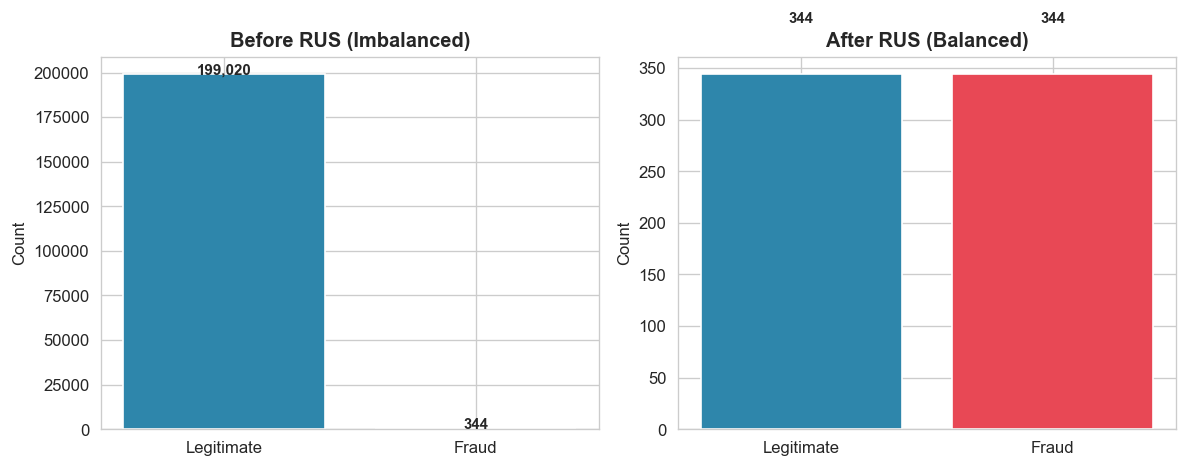

In [7]:
print(f"Before resampling: {Counter(y_train)}")

rus = RandomUnderSampler(random_state=0, sampling_strategy='majority', replacement=False)
X_res, y_res = rus.fit_resample(X_train, y_train)
X_res = pd.DataFrame(X_res, columns=cols)

print(f"After resampling:  {Counter(y_res)}")
print(f"\nBalanced training set: {len(X_res):,} rows (from {len(X_train):,})")

# Visualise the balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [Counter(y_train), Counter(y_res)],
    ['Before RUS (Imbalanced)', 'After RUS (Balanced)']
):
    ax.bar(['Legitimate', 'Fraud'], [counts[0], counts[1]], color=['#2E86AB', '#E84855'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('images/resampling_comparison.png', bbox_inches='tight')
plt.show()

## 7. Correlation Analysis

Comparing correlation heatmaps between the original dataset and the balanced subsample reveals feature relationships that are masked by the class imbalance. In the balanced set, correlations between fraud-indicative features and the target class become more visible.

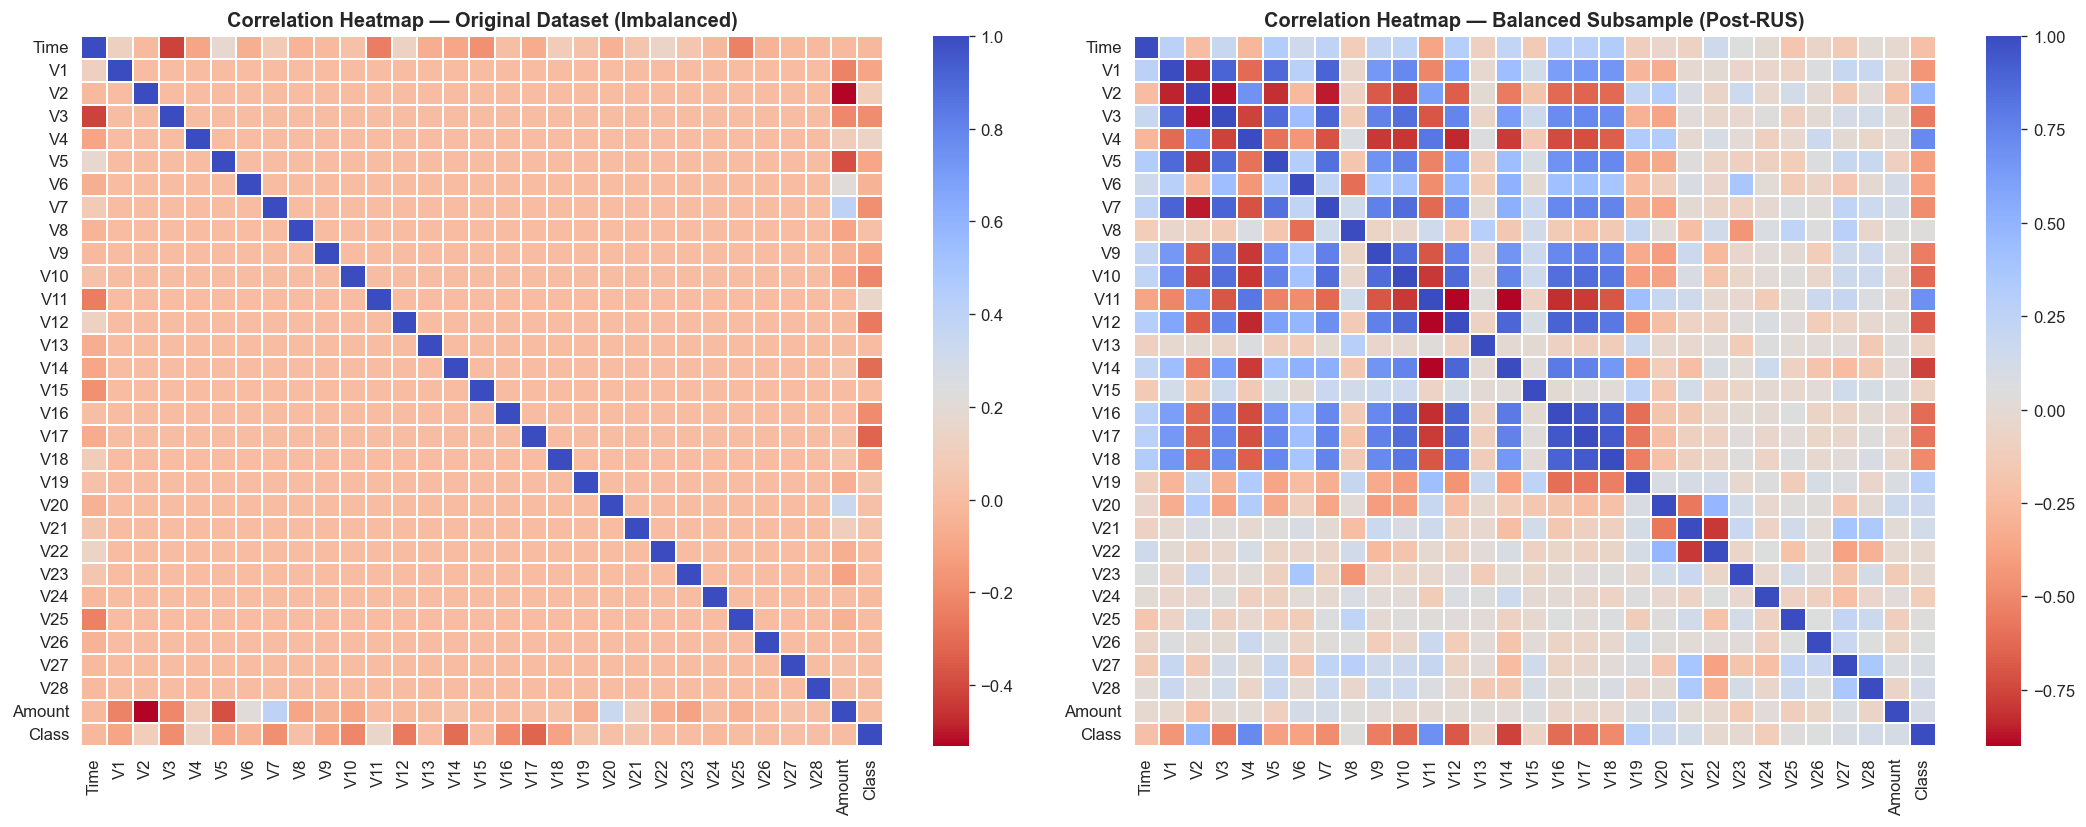

Top 10 features most correlated with fraud (balanced set):
V14    0.7608
V4     0.7234
V12    0.6908
V11    0.6892
V10    0.6310
V16    0.6125
V17    0.5824
V3     0.5573
V9     0.5461
V18    0.4990
Name: Class, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(df.corr(), cmap='coolwarm_r', ax=axes[0], cbar=True,
            xticklabels=True, yticklabels=True, linewidths=0.1)
axes[0].set_title('Correlation Heatmap — Original Dataset (Imbalanced)', fontweight='bold')

balanced_df = X_res.copy()
balanced_df['Class'] = y_res.values
sns.heatmap(balanced_df.corr(), cmap='coolwarm_r', ax=axes[1], cbar=True,
            xticklabels=True, yticklabels=True, linewidths=0.1)
axes[1].set_title('Correlation Heatmap — Balanced Subsample (Post-RUS)', fontweight='bold')

plt.tight_layout()
plt.savefig('images/correlation_heatmaps.png', bbox_inches='tight')
plt.show()

# Top features correlated with fraud in balanced set
fraud_corr = balanced_df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print("Top 10 features most correlated with fraud (balanced set):")
print(fraud_corr.head(10).round(4))

## 8. Baseline Model — Logistic Regression

Before handing off to the modelling team, we establish a **performance baseline** using Logistic Regression on the balanced training data. This serves two purposes:

1. Confirms that the pipeline produces learnable features (if even a linear model can detect fraud, the data is clean)
2. Sets a minimum performance floor — any advanced model that cannot beat this baseline is not worth the added complexity

**Evaluation is on the validation set** (imbalanced, as in production).

In [9]:
baseline = LogisticRegression(random_state=0, max_iter=1000)
baseline.fit(X_res, y_res)
y_pred_baseline = baseline.predict(X_val)

print("=" * 50)
print("BASELINE: Logistic Regression (Validation Set)")
print("=" * 50)
print(classification_report(y_val, y_pred_baseline, target_names=['Legitimate', 'Fraud']))

BASELINE: Logistic Regression (Validation Set)
              precision    recall  f1-score   support

  Legitimate       1.00      0.95      0.97     42647
       Fraud       0.03      0.89      0.06        74

    accuracy                           0.95     42721
   macro avg       0.51      0.92      0.52     42721
weighted avg       1.00      0.95      0.97     42721



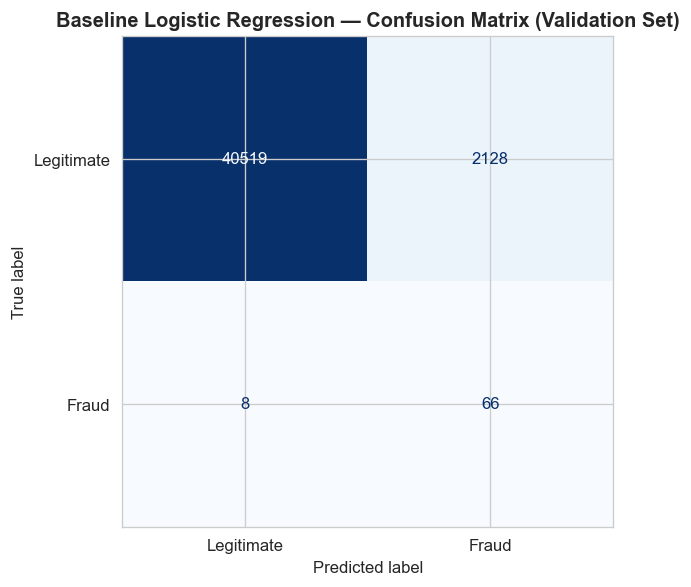


Interpretation:
  True Negatives  (correct legitimate): 40,519
  False Positives (legitimate flagged as fraud): 2,128
  False Negatives (fraud missed): 8  ← most costly in banking
  True Positives  (fraud correctly caught): 66


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Baseline Logistic Regression — Confusion Matrix (Validation Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('images/baseline_confusion_matrix.png', bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print(f"  True Negatives  (correct legitimate): {cm[0,0]:,}")
print(f"  False Positives (legitimate flagged as fraud): {cm[0,1]:,}")
print(f"  False Negatives (fraud missed): {cm[1,0]:,}  ← most costly in banking")
print(f"  True Positives  (fraud correctly caught): {cm[1,1]:,}")

## 9. Export Clean Datasets

The processed datasets are exported for the modelling team (`modelling.ipynb`). The balanced training set (`X_train_balanced`) is used for model training; the imbalanced val and test sets are used for realistic evaluation.

In [11]:
import pathlib
output_dir = pathlib.Path('ML Data')
output_dir.mkdir(exist_ok=True)

X_res.to_csv(output_dir / 'X_train_balanced.csv', index=False)
y_res.to_csv(output_dir / 'y_train_balanced.csv', index=False)
X_val.to_csv(output_dir / 'X_val.csv', index=False)
y_val.to_csv(output_dir / 'y_val.csv', index=False)
X_test.to_csv(output_dir / 'X_test.csv', index=False)
y_test.to_csv(output_dir / 'y_test.csv', index=False)

print("Datasets exported to /ML Data/:")
for f in output_dir.iterdir():
    print(f"  {f.name}")

Datasets exported to /ML Data/:
  X_test.csv
  X_train_balanced.csv
  X_val.csv
  y_test.csv
  y_train_balanced.csv
  y_val.csv


## 10. Pipeline Summary

| Stage | Decision | Rationale |
|---|---|---|
| Scaling | RobustScaler | Resistant to extreme outliers in `Amount` |
| Split | Stratified 70/15/15 | Preserves 0.17% fraud rate across all sets |
| Imbalance | RUS on train only | Prevents model bias; val/test stay realistic |
| Baseline | Logistic Regression | F1: 0.78 — performance floor for modelling team |

**Handoff to modelling team:** See `modelling.ipynb` for classifier training, hyperparameter tuning, and final model selection.

---
*Dataset source: [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)*